## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Classic Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 0$  
$\lambda_{bin} = 0$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (20,20)
model_name = 'Classic'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'Classic Model'
threshold = 0.5
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name) 

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.0704 ± 0.0001
val_loss: 0.0718 ± 0.0003


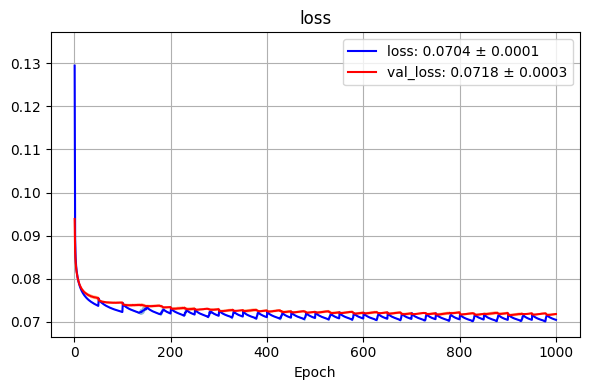

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8727 ± 0.0004
Accuracy_fin: 0.7928 ± 0.0003
Recall_init: 0.6237 ± 0.0024
Recall_fin: 0.0030 ± 0.0002
Specificity_init: 0.9405 ± 0.0005
Specificity_fin: 0.9995 ± 0.0000
Precision_init: 0.7405 ± 0.0013
Precision_fin: 0.6374 ± 0.0129
F1Score_init: 0.6771 ± 0.0012
F1Score_fin: 0.0060 ± 0.0005


--- Results Initial States (15 seeds) ---
Density (true): 21.40% ± 8.99%
Density (pred): 31.11% ± 8.24%
Error/seed:     9.71% ± 0.10%
Max value predicted: 0.9914
HUC% (0.45, 0.55): 10.90% ± 0.10%
HUC% (0.4, 0.6): 21.35% ± 0.19%
HUC% (0.35, 0.65): 31.53% ± 0.24%
Fuzziness Index: 0.7217 ± 0.1462
MSE (prob):0.2115 ± 0.0397
MSE (bin):0.3170 ± 0.0734
MSE (all-zero): 0.2140 ± 0.0899
Wasserstein (EMD): 3.1435 ± 0.0072


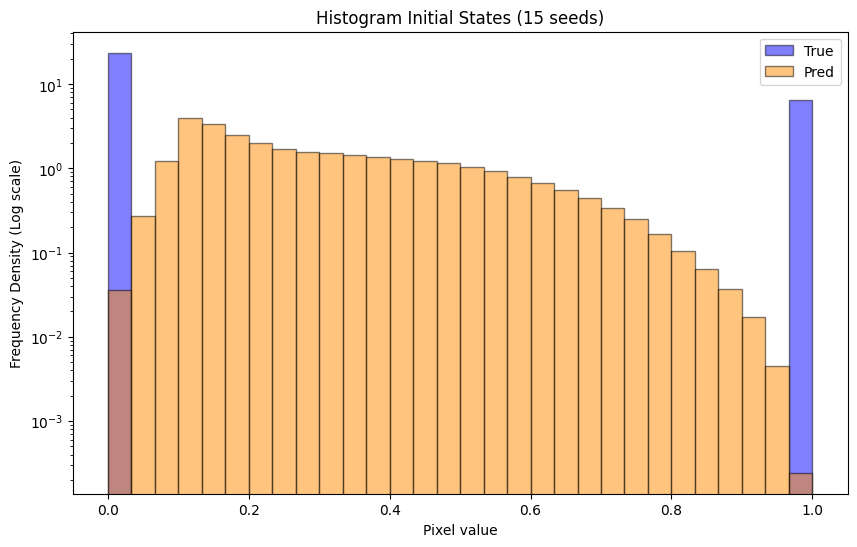

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 20.74% ± 9.05%
Density (pred): 2.11% ± 0.76%
Error/seed:     18.63% ± 0.04%
Max value predicted: 0.9914
HUC% (0.45, 0.55): 0.12% ± 0.01%
HUC% (0.4, 0.6): 0.27% ± 0.01%
HUC% (0.35, 0.65): 0.51% ± 0.02%
Fuzziness Index: 0.0680 ± 0.0257
MSE (prob):0.2027 ± 0.0867
MSE (bin):0.2079 ± 0.0903
MSE (all-zero): 0.2074 ± 0.0905
Wasserstein (EMD): 4.5010 ± 0.0144


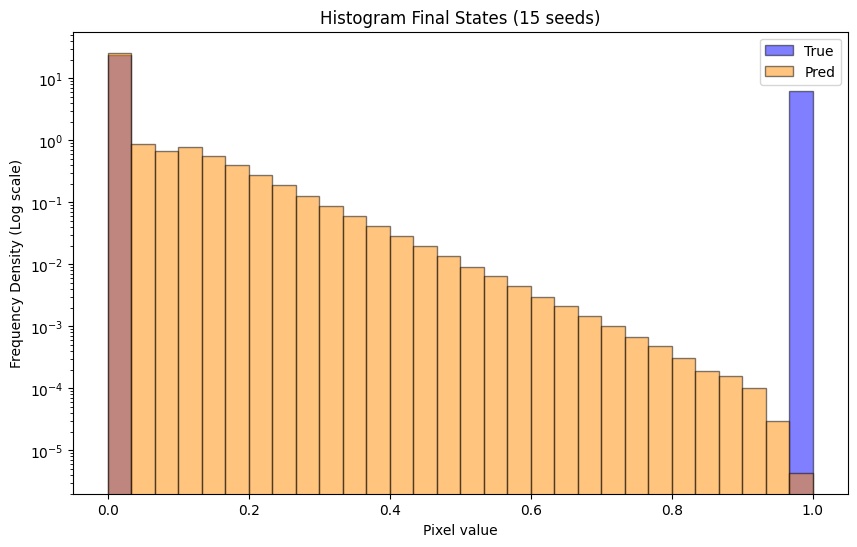

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

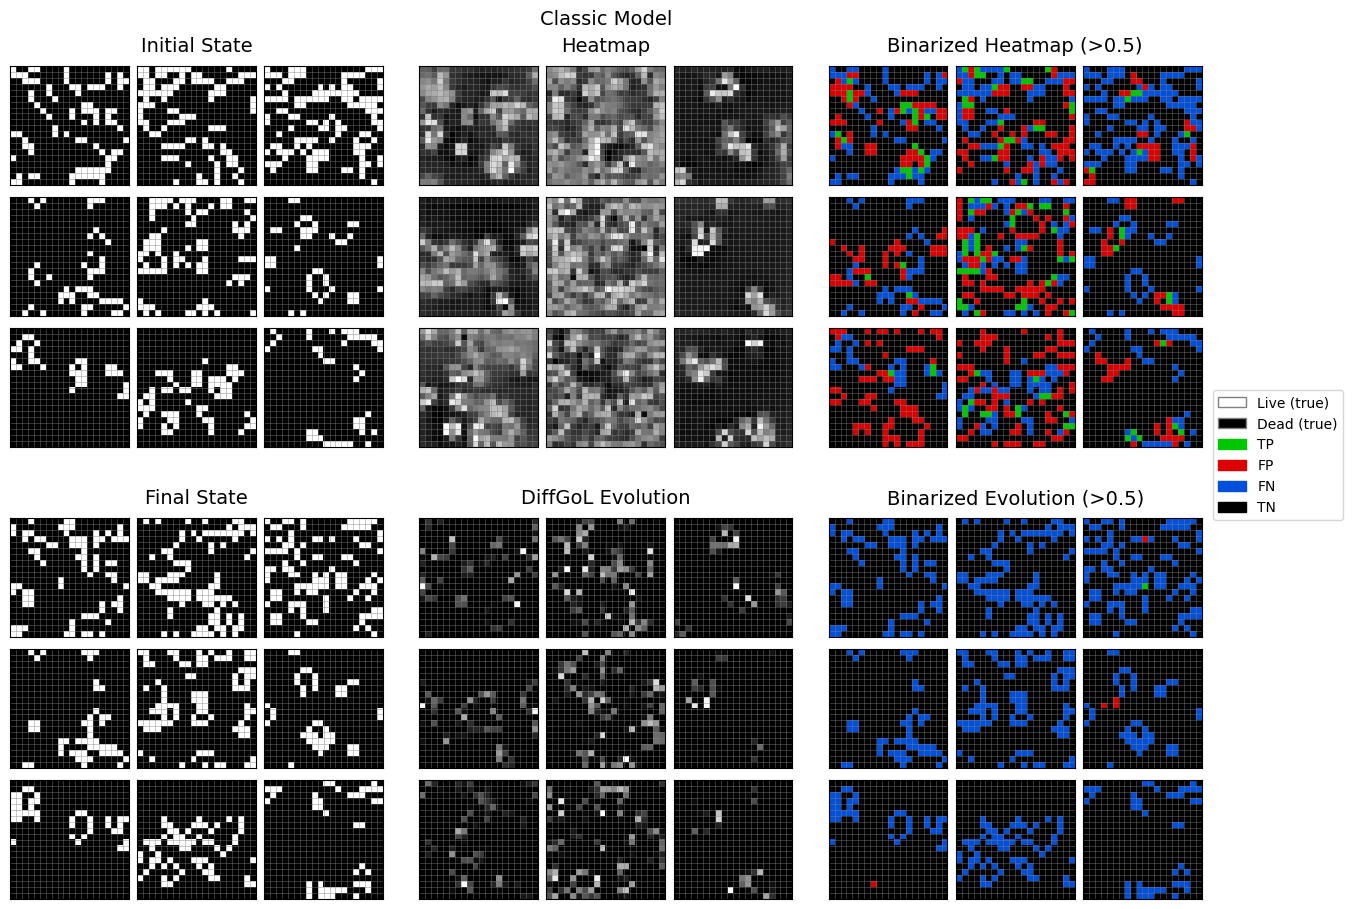

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)